In [18]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import config

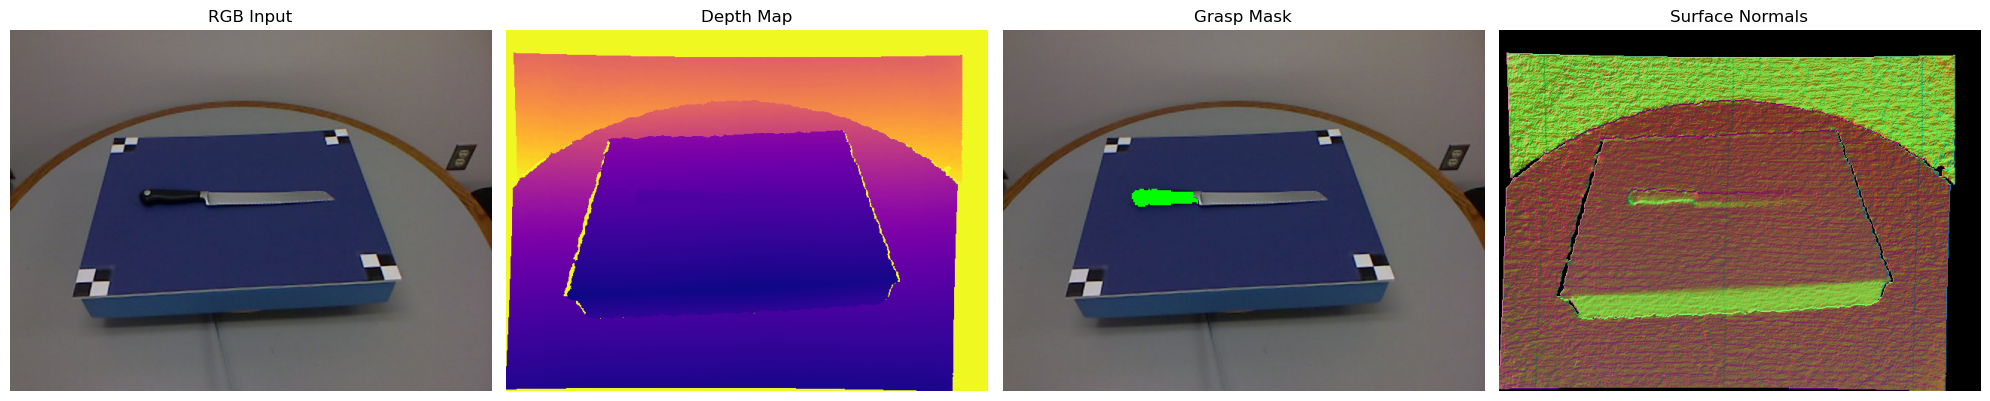

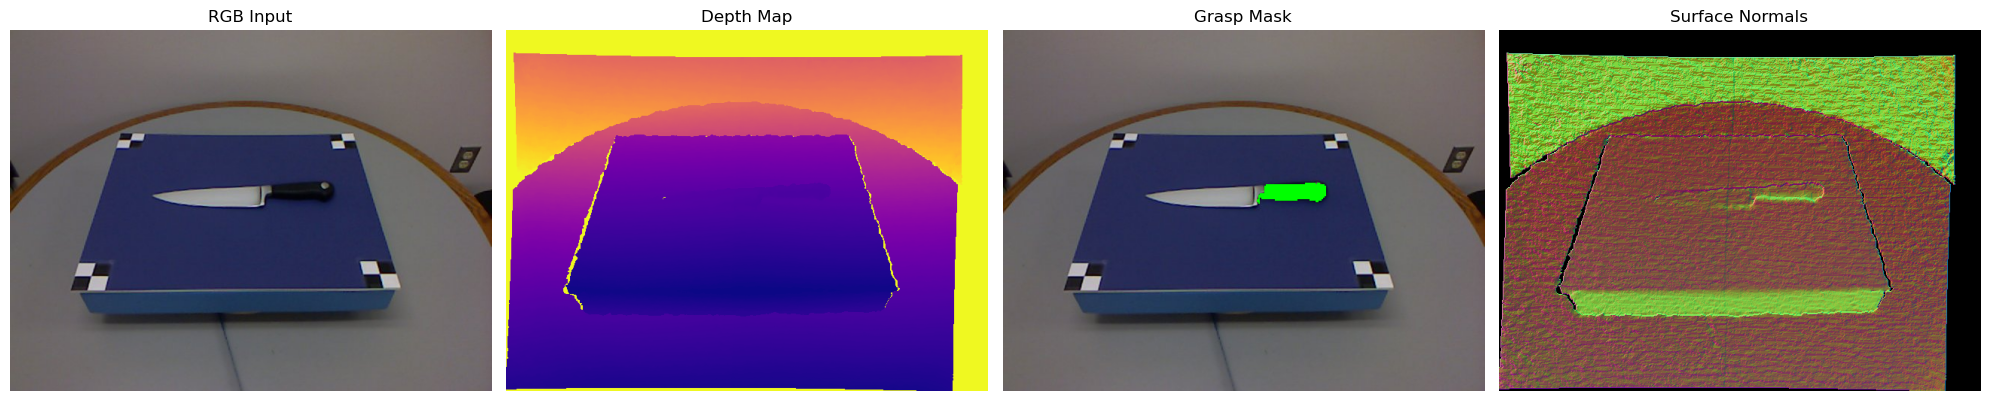

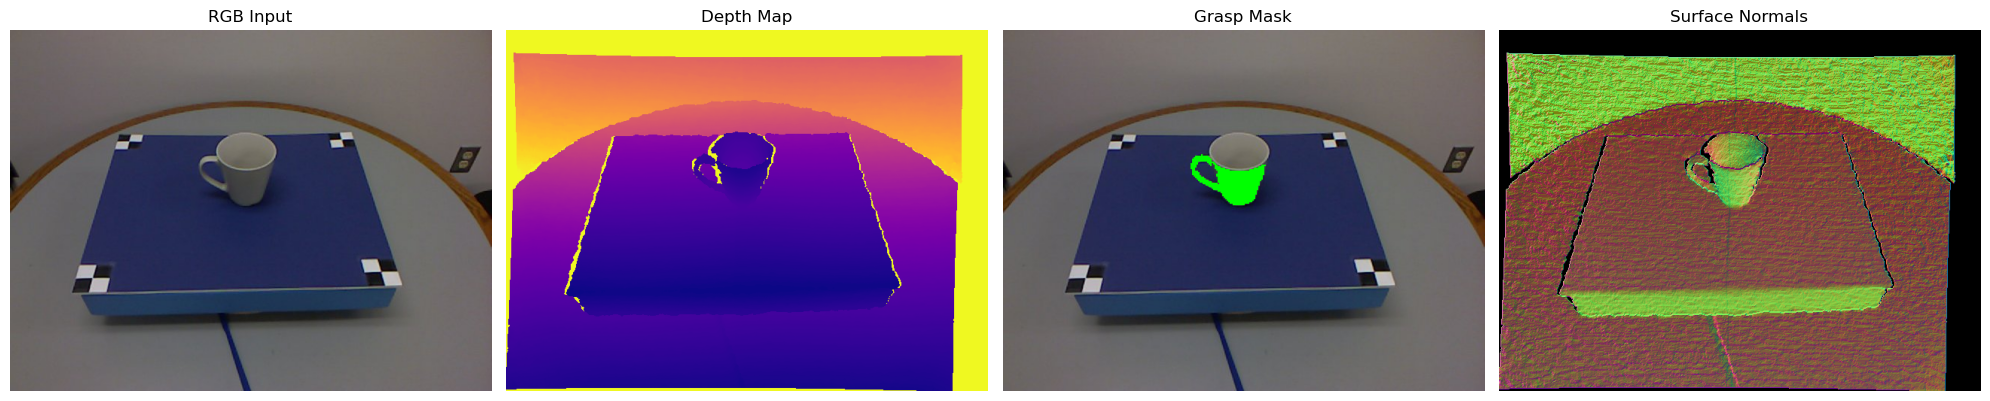

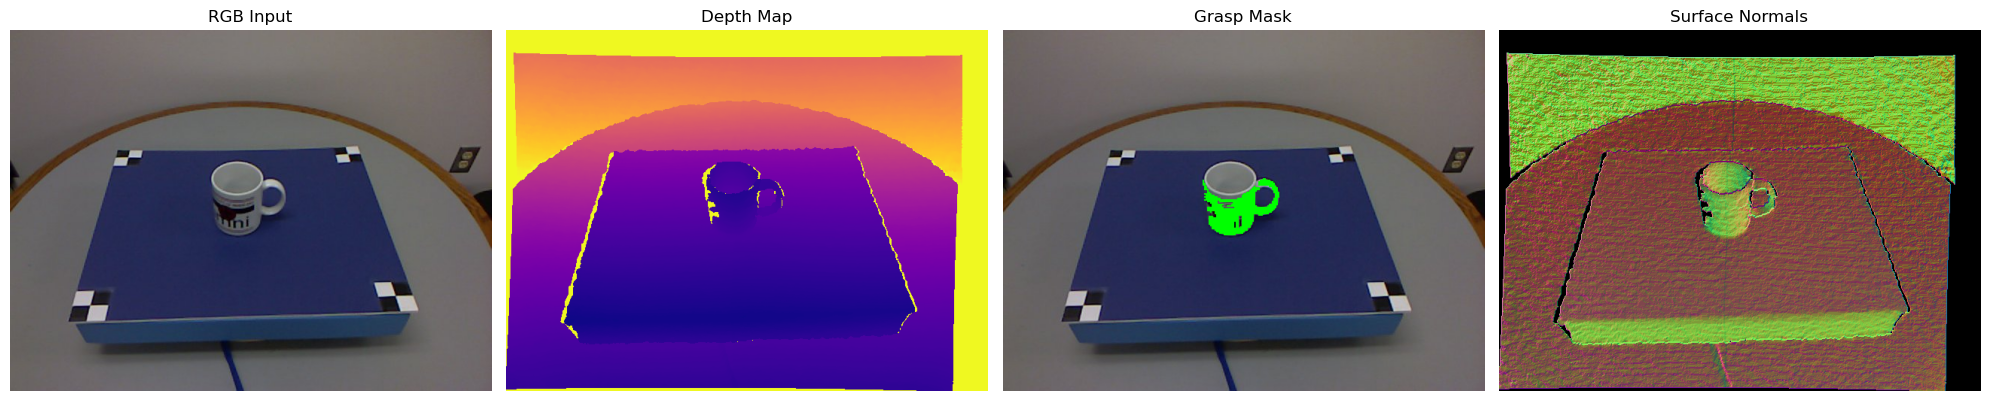

In [19]:
from utils.visualization import visualize_sample

visualize_sample(str(config.RAW_TOOLS), tool_instance="knife_01", frame_idx=1)
visualize_sample(str(config.RAW_TOOLS), tool_instance="knife_03", frame_idx=1)
visualize_sample(str(config.RAW_TOOLS), tool_instance="mug_01", frame_idx=1)
visualize_sample(str(config.RAW_TOOLS), tool_instance="mug_04", frame_idx=1)

In [20]:
from utils.dataset import UMDAffordanceDataset
from torch.utils.data import DataLoader

# 1. Initialize the dataset
dataset = UMDAffordanceDataset(base_dir=config.RAW_TOOLS)
print(f"Total valid training samples found: {len(dataset)}")

# 2. Wrap it in a DataLoader (simulates what training will do)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# 3. Fetch one batch of 4 images
batch = next(iter(dataloader))

print("\n--- Tensor Shapes for the Neural Network ---")
print(f"RGB Batch:     {batch['rgb'].shape}     | Min: {batch['rgb'].min():.2f}, Max: {batch['rgb'].max():.2f}")
print(f"Depth Batch:   {batch['depth'].shape}   | (Meters)")
print(f"Mask Batch:    {batch['mask'].shape}    | Min: {batch['mask'].min():.0f}, Max: {batch['mask'].max():.0f}")
print(f"Normals Batch: {batch['normals'].shape} | Vectors [-1 to 1]")
print(f"Tools in batch: {batch['tool_name']}")

Total valid training samples found: 28843

--- Tensor Shapes for the Neural Network ---
RGB Batch:     torch.Size([4, 3, 480, 640])     | Min: 0.00, Max: 1.00
Depth Batch:   torch.Size([4, 1, 480, 640])   | (Meters)
Mask Batch:    torch.Size([4, 1, 480, 640])    | Min: 0, Max: 1
Normals Batch: torch.Size([4, 3, 480, 640]) | Vectors [-1 to 1]
Tools in batch: ['saw_02', 'saw_03', 'knife_06', 'knife_08']


In [21]:
import torch
from models.backbone import DINOv2Backbone

# 1. Initialize the backbone
print("Downloading/Loading DINOv2...")
# This will download about 85MB of weights from Facebook's servers the first time you run it
backbone = DINOv2Backbone(freeze=True)

# 2. Get the RGB batch from our previous DataLoader cell
rgb_batch = batch['rgb']

# CRITICAL FIX: Crop to the nearest multiples of 14 (476 x 630)
# 476 / 14 = 34 patches tall
# 630 / 14 = 45 patches wide
rgb_cropped = rgb_batch[:, :, :476, :630]

# 3. Pass it through the brain!
print(f"Feeding {rgb_cropped.shape} images to DINOv2...")

# We use torch.no_grad() because we froze the model and don't want to waste RAM tracking gradients
with torch.no_grad(): 
    semantic_features = backbone(rgb_cropped)

print("\n--- Semantic Output ---")
print(f"Input Shape:  {rgb_cropped.shape}  [Batch, RGB, Height, Width]")
print(f"Output Shape: {semantic_features.shape} [Batch, Embed_Dim, Feature_H, Feature_W]")

Downloading/Loading DINOv2...


Using cache found in /Users/francesco/.cache/torch/hub/facebookresearch_dinov2_main


Feeding torch.Size([4, 3, 476, 630]) images to DINOv2...

--- Semantic Output ---
Input Shape:  torch.Size([4, 3, 476, 630])  [Batch, RGB, Height, Width]
Output Shape: torch.Size([4, 384, 34, 45]) [Batch, Embed_Dim, Feature_H, Feature_W]
